In [ ]:
# project description:
# 

In [4]:
!pip install plotly pandas requests geopy

In [6]:
import pandas as pd
import requests
from io import StringIO

dc_url = "https://epoch.ai/data/data_centers/data_centers.csv"
tl_url = "https://epoch.ai/data/data_centers/data_center_timelines.csv"

dc_raw = requests.get(dc_url).text
tl_raw = requests.get(tl_url).text

dc = pd.read_csv(StringIO(dc_raw))
tl = pd.read_csv(StringIO(tl_raw))

print(dc.shape, dc.columns.tolist())
print(tl.shape, tl.columns.tolist())

(43, 15) ['Name', 'Current H100 equivalents', 'Current power (MW)', 'Current total capital cost (2025 USD billions)', 'Owner', 'Users', 'Notes', 'Selected Sources', 'Calculations sheet', 'Project', 'Investors', 'Construction companies', 'Energy companies', 'Country', 'Address']
(247, 14) ['Date', 'Construction status', 'Buildings operational', 'IT power (MW)', 'Power (MW)', 'H100 equivalents', 'Total capital cost (2025 USD billions)', 'Performance (8-bit OP/s)', 'Compute cost (2025 USD billions)', 'Construction cost (2025 USD billions)', 'Water use (MGD)', 'Data center', 'Current H100 equivalents (from Data center)', 'Thumbnail']


In [8]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

us_dc = dc[dc['Country'] == 'United States'].copy()
us_dc = us_dc[us_dc['Address'].notna()].copy()

us_dc['Owner_clean'] = us_dc['Owner'].str.replace(r'\s*#\w+', '', regex=True).str.strip()
us_dc['Owner_clean'] = us_dc['Owner_clean'].fillna('Unknown')

geolocator = Nominatim(user_agent="datacenter_map")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def get_coords(address):
    try:
        loc = geocode(address, timeout=10)
        if loc:
            return loc.latitude, loc.longitude
    except:
        pass
    return None, None

us_dc[['lat', 'lon']] = us_dc['Address'].apply(
    lambda a: pd.Series(get_coords(a))
)

print(us_dc[['Name', 'Owner_clean', 'lat', 'lon']].to_string())

                             Name Owner_clean        lat         lon
0                      Colossus 2    SpaceXAI  34.997983  -90.034867
1     Microsoft Fairwater Atlanta   Microsoft  33.445492  -84.524115
2   Anthropic-Amazon New Carlisle      Amazon        NaN         NaN
3   Microsoft Fairwater Wisconsin   Microsoft  42.674872  -87.894882
4                 Meta Prometheus        Meta        NaN         NaN
5                    QTS Richmond     Unknown  37.488827  -77.247490
6                      Colossus 1    SpaceXAI  35.073554  -90.087308
7         OpenAI Stargate Abilene      Oracle  32.494232  -99.800907
8                 Google Columbus      Google  39.861452  -83.004000
9        Amazon Madison Mega Site      Amazon        NaN         NaN
10              Google New Albany      Google  40.070051  -82.754042
11             Microsoft Goodyear   Microsoft  33.408991 -112.364800
12                    Meta Temple        Meta  31.126016  -97.360000
13                   Google Omaha 

In [10]:
# Fix casing
us_dc['Owner'] = us_dc['Owner_clean'].replace('Coreweave', 'CoreWeave')
us_dc['Owner'] = us_dc['Owner'].str.replace(r'\s*#\w+', '', regex=True).str.strip()
us_dc['Owner'] = us_dc['Owner'].fillna('Unknown')

# Manual coords for failed geocoding
manual_coords = {
    'Anthropic-Amazon New Carlisle': (41.7009, -86.5220),
    'Meta Prometheus':               (40.0742, -82.7913),
    'Amazon Madison Mega Site':      (32.6121, -90.0357),
    'Microsoft Project Osmium':      (41.5051, -93.9856),
    'Goodnight':                     (34.9770, -101.3569),
    'Coreweave Helios':              (33.0373, -100.9218),
    'OpenAI Stargate Shackelford':   (32.4940, -99.8007),
    'OpenAI Stargate Lordstown':     (41.2387, -80.8151),
    'OpenAI Stargate New Mexico':    (35.0853, -106.6500),
    'OpenAI Stargate Wisconsin':     (43.0731, -89.4012),
    'OpenAI Stargate Michigan':      (42.3314, -83.0458),
    'OpenAI Stargate Milam':         (30.7552, -96.9997),
    'Google Kansas City East':       (39.0997, -94.5786),
    'Vantage TX1':                   (33.4484, -112.3740),
}

for name, (lat, lon) in manual_coords.items():
    mask = us_dc['Name'] == name
    us_dc.loc[mask, 'lat'] = lat
    us_dc.loc[mask, 'lon'] = lon

print(f"Missing coords remaining: {us_dc['lat'].isna().sum()}")

# Prep timeline
tl['Date'] = pd.to_datetime(tl['Date'])
tl['Year'] = tl['Date'].dt.year
tl_op = tl[tl['Power (MW)'] > 0].copy()
tl_yearly = (
    tl_op.groupby(['Data center', 'Year'])['Power (MW)']
    .max()
    .reset_index()
)

Missing coords remaining: 0


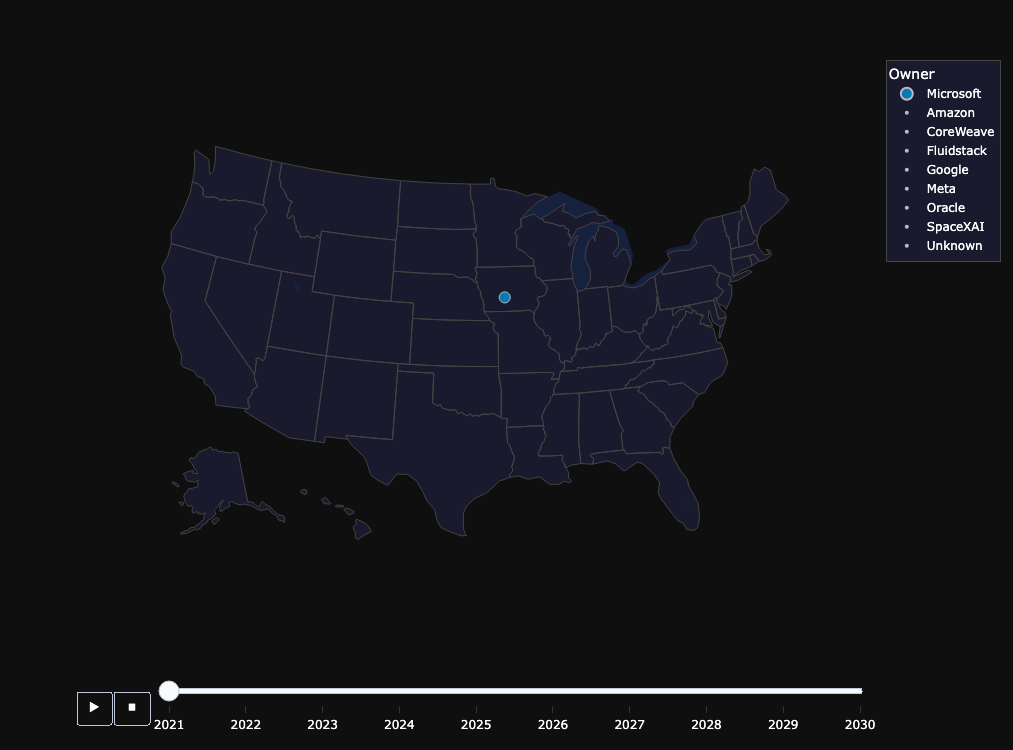

In [36]:
import plotly.express as px

merged = tl_yearly.merge(
    us_dc[['Name', 'Owner', 'lat', 'lon']],
    left_on='Data center',
    right_on='Name',
    how='inner'
)

all_years = sorted(range(merged['Year'].min(), merged['Year'].max() + 1))
rows = []
for name in merged['Name'].unique():
    site = merged[merged['Name'] == name].set_index('Year')
    owner = us_dc.loc[us_dc['Name'] == name, 'Owner'].iloc[0]
    lat = site['lat'].iloc[0]
    lon = site['lon'].iloc[0]
    for year in all_years:
        past = site[site.index <= year]
        if not past.empty:
            power = past['Power (MW)'].max()
            rows.append({
                'Name': name,
                'Owner': owner,
                'lat': lat,
                'lon': lon,
                'Power (MW)': power,
                'Year': str(year),
            })

anim_df = pd.DataFrame(rows)

all_owners = anim_df['Owner'].unique()
dummy_rows = []
for year in [str(y) for y in all_years]:
    for owner in all_owners:
        dummy_rows.append({
            'Name': f'__dummy_{owner}',
            'Owner': owner,
            'lat': 38.5, 'lon': -98.0,
            'Power (MW)': 0,
            'Year': year,
        })

anim_df = pd.concat([anim_df, pd.DataFrame(dummy_rows)], ignore_index=True)
anim_df = anim_df.sort_values(['Year', 'Name'])

owner_colors = {
    'Microsoft':  '#00a2ed',
    'Meta':       '#1877f2',
    'Google':     '#34a853',
    'Amazon':     '#ff9900',
    'Oracle':     '#f80000',
    'SpaceXAI':   '#cc0000',
    'CoreWeave':  '#7b2d8b',
    'Fluidstack': '#00b4d8',
    'Unknown':    '#aaaaaa',
    'Softbank':   '#cc6600',
}

fig = px.scatter_geo(
    anim_df,
    lat='lat', lon='lon',
    size='Power (MW)',
    color='Owner',
    hover_name='Name',
    hover_data={'Power (MW)': True, 'Owner': True, 'lat': False, 'lon': False},
    animation_frame='Year',
    scope='usa',
    size_max=60,
    color_discrete_map=owner_colors,
)

fig.update_layout(
    geo=dict(
        bgcolor='#0f0f0f',
        landcolor='#1a1a2e',
        lakecolor='#16213e',
        subunitcolor='#444',
        showland=True,
        showlakes=True,
        showsubunits=True,
    ),
    paper_bgcolor='#0f0f0f',
    plot_bgcolor='#0f0f0f',
    font=dict(color='white'),
    legend=dict(bgcolor='#1a1a2e', bordercolor='#444', borderwidth=1),
    title=dict(
        x=0.5,
        font=dict(size=18),
    ),
    height=750,
)

fig.update_traces(
    hovertemplate='<b>%{hovertext}</b><br>Owner = %{customdata[0]}<br>Power (MW) = %{customdata[1]}<extra></extra>'
)

fig.layout.sliders[0].currentvalue.visible = False
for button in fig.layout.updatemenus[0].buttons:
    button.args[1]['frame']['duration'] = 800

fig.show()

In [38]:
import base64

with open('/Users/oliviadh/qiong_python_projs/original_7c9150805920c2dacb31faa9a11444be.webp', 'rb') as f:
    img_data = base64.b64encode(f.read()).decode('utf-8')
img_src = f"data:image/webp;base64,{img_data}"

html = fig.to_html(full_html=False, include_plotlyjs='cdn')

full_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Tracking US AI Data Centers</title>
    <style>
        *, *::before, *::after {{ margin: 0; padding: 0; box-sizing: border-box; }}

        :root {{
            --bg: #0C0C0C;
            --white: #EAEAEA;
            --dim: #A4A4A4;
            --border: #1e1e1e;
            --font: 'Helvetica Neue', 'HelveticaNeue', Helvetica, Arial, sans-serif;
            --mono: 'Roboto Mono', Roboto, monospace;
        }}

        html, body {{
            height: 100%;
            background: var(--bg);
            color: var(--white);
            font-family: var(--font);
            overflow: hidden;
        }}

        nav {{
            position: fixed;
            top: 0; left: 0; right: 0;
            z-index: 100;
            display: flex;
            justify-content: space-between;
            align-items: center;
            padding: 32px 48px;
            background: rgba(10, 10, 10, 0.6);
            backdrop-filter: blur(16px);
            -webkit-backdrop-filter: blur(16px);
        }}

        .nav-logo {{
            font-size: 0.7rem;
            letter-spacing: 0.18em;
            text-transform: uppercase;
            color: var(--dim);
            font-family: var(--mono);
        }}

        .nav-toggle {{
            display: flex;
            background: #111;
            border: 1px solid #2a2a2a;
            border-radius: 100px;
            padding: 5px;
            gap: 2px;
            position: relative;
        }}

        .toggle-btn {{
            position: relative;
            z-index: 1;
            padding: 9px 22px;
            border-radius: 100px;
            font-size: 0.72rem;
            letter-spacing: 0.12em;
            text-transform: uppercase;
            font-weight: 600;
            font-family: var(--font);
            color: var(--white);
            background: transparent;
            border: none;
            cursor: pointer;
            transition: color 0.3s ease;
            display: flex;
            align-items: center;
            gap: 7px;
        }}

        .toggle-btn.active {{ color: #0a0a0a; }}

        .toggle-pill {{
            position: absolute;
            top: 5px;
            height: calc(100% - 10px);
            background: var(--white);
            border-radius: 100px;
            transition: left 0.35s cubic-bezier(0.4, 0, 0.2, 1), width 0.35s cubic-bezier(0.4, 0, 0.2, 1);
            z-index: 0;
        }}

        .nav-right {{
            font-family: var(--mono);
            font-size: 0.7rem;
            color: var(--dim);
            letter-spacing: 0.12em;
            text-transform: uppercase;
        }}

        .page {{
            position: fixed;
            inset: 0;
            opacity: 0;
            pointer-events: none;
            transition: opacity 0.4s ease;
            overflow-y: auto;
        }}

        .page.active {{
            opacity: 1;
            pointer-events: all;
        }}

        #map-page {{ background: var(--bg); }}

        #map-page .plotly-graph-div {{
            width: 100% !important;
            height: calc(100vh - 200px) !important;
        }}

        .map-header {{
            padding: 120px 64px 56px;
            display: flex;
            justify-content: space-between;
            align-items: flex-end;
            border-bottom: 1px solid var(--border);
        }}

        .map-header h2 {{
            font-size: 3em;
            font-weight: 500;
            letter-spacing: 0.02em;
            line-height: 0.95;
            color: var(--white);
        }}

        .map-meta {{
            font-family: var(--mono);
            font-size: 0.65rem;
            color: var(--dim);
            letter-spacing: 0.08em;
            text-align: right;
            line-height: 2;
        }}

        #info-page {{ background: var(--bg); }}

        .info-hero {{
            padding: 120px 64px 56px;
            border-bottom: 1px solid var(--border);
        }}

        .info-hero h2 {{
            font-size: 3em;
            font-weight: 500;
            letter-spacing: 0.02em;
            line-height: 0.95;
            color: var(--white);
        }}

        .info-body {{
            display: grid;
            grid-template-columns: 1fr 1fr;
            border-bottom: 1px solid var(--border);
        }}

        .info-col {{
            padding: 56px 64px;
        }}

        .info-col + .info-col {{ border-left: 1px solid var(--border); }}

        .col-label {{
            font-family: var(--mono);
            font-size: 0.65rem;
            letter-spacing: 0.18em;
            text-transform: uppercase;
            color: var(--dim) !important;
            margin-bottom: 40px;
        }}

        .stat {{ margin-bottom: 44px; }}

        .stat .fig {{
            font-size: 3.8rem;
            font-weight: 400;
            line-height: 1;
            margin-bottom: 10px;
            color: var(--white);
        }}

        .stat .note {{
            font-size: 0.88rem;
            color: var(--white);
            line-height: 1.95;
            max-width: 360px;
            font-weight: 300;
            letter-spacing: 0.05em;
        }}

        .info-col p {{
            font-size: 0.92rem;
            color: var(--white);
            line-height: 1.95;
            margin-bottom: 22px;
            font-weight: 300;
            letter-spacing: 0.05em;
        }}

        .info-col p strong {{
            color: var(--white);
            font-weight: 300;
        }}

        .pull {{
            padding: 56px 64px;
            border-bottom: 1px solid var(--border);
        }}

        .pull blockquote {{
            font-size: clamp(1.3rem, 2.2vw, 2rem);
            font-weight: 400;
            line-height: 1.5;
            letter-spacing: 0.01em;
            max-width: 780px;
            color: var(--white);
        }}

        .pull cite {{
            display: block;
            margin-top: 20px;
            font-size: 0.68rem;
            font-family: var(--mono);
            color: var(--dim);
            letter-spacing: 0.1em;
            font-style: normal;
        }}

        footer {{
            padding: 28px 64px;
            display: flex;
            justify-content: space-between;
            border-top: 1px solid var(--border);
        }}

        footer span {{
            font-family: var(--mono);
            font-size: 0.65rem;
            color: var(--dim);
            letter-spacing: 0.08em;
        }}
    </style>
</head>
<body>

<nav>
    <span class="nav-logo">US AI Data Centers</span>
    <div class="nav-toggle" id="navToggle">
        <div class="toggle-pill" id="togglePill"></div>
        <button class="toggle-btn active" id="btn-map" onclick="showPage('map-page', 0)">
            <svg xmlns="http://www.w3.org/2000/svg" width="16" height="16" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round">
                <path d="M20 10c0 6-8 12-8 12s-8-6-8-12a8 8 0 0 1 16 0Z"/>
                <circle cx="12" cy="10" r="3"/>
            </svg>
        </button>
        <button class="toggle-btn" id="btn-about" onclick="showPage('info-page', 1)">
            <svg xmlns="http://www.w3.org/2000/svg" width="13" height="13" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round">
                <line x1="3" y1="6" x2="21" y2="6"/>
                <line x1="3" y1="12" x2="21" y2="12"/>
                <line x1="3" y1="18" x2="21" y2="18"/>
            </svg>
        </button>
    </div>
    <span class="nav-right">2021-2030</span>
</nav>

<!-- MAP PAGE -->
<div class="page active" id="map-page">
    <div class="map-header">
        <h2>Tracking US AI Data Centers 2021-2030</h2>
        <div class="map-meta">
            Source: Epoch AI Frontier Database<br>
            Bubble size = power capacity (MW)<br>
            Post-2026 entries are projections
        </div>
    </div>
    {html}
    <footer>
        <span>Data: epoch.ai/data/data-centers</span>
        <span>Built with Python + Plotly</span>
    </footer>
</div>

<!-- INFO PAGE -->
<div class="page" id="info-page">
    <div class="info-hero">
        <h2>The Rise of Technofeudalism and AI Data Centers</h2>
    </div>
    <div class="info-body">
        <div class="info-col">
            <p class="col-label">By the Numbers</p>
            <div class="stat">
                <div class="fig">1–5M</div>
                <div class="note">Gallons of water consumed per day by a single large AI data center, primarily for cooling. Comparable to a mid-sized city.</div>
            </div>
            <div class="stat">
                <div class="fig">~2%</div>
                <div class="note">Share of global electricity currently consumed by data centers. AI workloads are projected to push this significantly higher by 2030.</div>
            </div>
            <div class="stat">
                <div class="fig">$500B+</div>
                <div class="note">Announced AI infrastructure investment by Microsoft, Google, Meta, and Amazon in 2024–2025 alone — concentrated almost entirely in the US.</div>
            </div>
        </div>
        <div class="info-col">
            <p class="col-label">The Bigger Picture</p>
            <p>Since 2021, a small handful of Big Tech companies have been in an arms race to build the physical infrastructure behind AI. These facilities consume acres of land, millions of gallons of water daily, and are projected to account for a growing share of global electricity — costs that are quietly passed on to ordinary households. According to Bloomberg, the average American electricity bill has already risen by $15–$30 per month as a direct result.</p>
            <p>The land these companies buy is almost always cheap and rural — towns that welcomed the investment hoping for jobs and tax revenue. What they got instead were automated facilities that employ a skeleton crew of engineers and security guards. The construction workers leave when the building is done. The permanent jobs never arrive. Meanwhile, local water tables drop and the grid strains under the load.</p>
            <p>Varoufakis calls this <strong>technofeudalism</strong> — not because it looks like the Middle Ages, but because the logic is the same. A small group owns the land everyone has to work on. They didn't build it to compete. They built it to collect. They own the infrastructure everyone else depends on, extract value from it continuously, and answer to no one in the communities bearing the costs. The data center is the new factory, except the factory floor is largely empty.</p>
            <p>Behind every megawatt on this map is a land deal, a water permit, a tax incentive, and a set of choices about who benefits and who pays. The answers are almost never the same people.</p>
            <div style="margin-top: 32px; padding: 20px 24px; border-left: 2px solid var(--dim); background: rgba(255,255,255,0.03);">
                <p style="font-family: var(--mono); font-size: 0.65rem; letter-spacing: 0.12em; text-transform: uppercase; color: var(--dim); margin-bottom: 8px;">Definition</p>
                <p style="font-size: 0.82rem; color: var(--dim); line-height: 1.8; margin: 0; font-weight: 300; letter-spacing: 0.03em;"><strong style="color: var(--white); font-weight: 400;">Technofeudalism</strong> — term coined by economist Yanis Varoufakis to describe an economic system in which digital platforms have displaced traditional capitalism. Rather than competing in open markets, tech giants now function as feudal lords — owning the infrastructure (cloud, data, AI compute) on which everyone else depends, and extracting perpetual rent from its use. <em>Technofeudalism: What Killed Capitalism</em>, Varoufakis, 2023.</p>
            </div>
        </div>
    </div>
    <div class="pull">
        <blockquote>
            "We are witnessing the enclosure of digital commons — the transformation of shared computational potential into private infrastructure controlled by a shrinking number of actors."
            <cite>— Adapted from Yanis Varoufakis, Technofeudalism (2023)</cite>
        </blockquote>
    </div>
    <footer>
        <span>© 2026 — Olivia Hamilton</span>
        <span>Built with Python · Plotly · Epoch AI data</span>
    </footer>
</div>

<script>
    const btns = [document.getElementById('btn-map'), document.getElementById('btn-about')];
    const pill = document.getElementById('togglePill');

    function movePill(idx) {{
        const btn = btns[idx];
        pill.style.left = btn.offsetLeft + 'px';
        pill.style.width = btn.offsetWidth + 'px';
    }}

    function showPage(pageId, btnIdx) {{
        document.querySelectorAll('.page').forEach(p => p.classList.remove('active'));
        document.getElementById(pageId).classList.add('active');
        btns.forEach(b => b.classList.remove('active'));
        btns[btnIdx].classList.add('active');
        movePill(btnIdx);
    }}

    window.addEventListener('load', () => movePill(0));
    window.addEventListener('resize', () => {{
        const active = btns.findIndex(b => b.classList.contains('active'));
        movePill(active >= 0 ? active : 0);
    }});
</script>

</body>
</html>"""

with open('ai_datacenters_animated.html', 'w') as f:
    f.write(full_html)
print("Saved.")

Saved.
